# 03 - Regularization & Data Augmentation on Real MNIST (GPU Accelerated)

This notebook covers **CNN regularization and image augmentation** on `MNIST` with **CUDA GPU Acceleration**.

---

## Topics Covered:

1. **GPU Config**: Moving `MNIST` batches to `device`.
2. **Data Augmentation (`torchvision.transforms`)**: Crop, Flip, Jitter on GPU pipelines.
3. **Spatial BatchNorm & Spatial Dropout** on GPU tensors.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as torch_optim
from torch.utils.data import DataLoader, Subset

import torchvision.transforms as T
from torchvision.datasets import MNIST

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device: {device}")

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')


Using Device: cpu


## 1. MNIST Dataset & Transforms


In [2]:
train_transform = T.Compose([
    T.RandomCrop(28, padding=4),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(mean=(0.1307,), std=(0.3081,))
])

test_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=(0.1307,), std=(0.3081,))
])

mnist_aug = MNIST(root='./data', train=True, download=True, transform=train_transform)
mnist_test = MNIST(root='./data', train=False, download=True, transform=test_transform)

train_aug_loader = DataLoader(Subset(mnist_aug, list(range(1000))), batch_size=32, shuffle=True)
test_loader = DataLoader(Subset(mnist_test, list(range(300))), batch_size=32, shuffle=False)


## 2. Models & GPU Training Benchmark


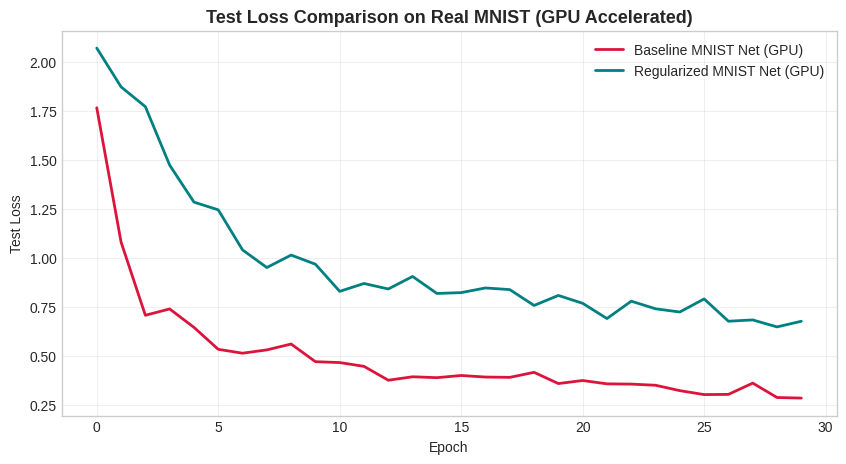

In [3]:
class BaselineMNISTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Flatten(),
            nn.Linear(64 * 14 * 14, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x): return self.net(x)

class RegularizedMNISTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.drop2d = nn.Dropout2d(p=0.2)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 14 * 14, 128)
        self.drop1d = nn.Dropout(p=0.4)
        self.fc2 = nn.Linear(128, 10)
        
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.drop2d(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.drop1d(x)
        return self.fc2(x)

base_net = BaselineMNISTNet().to(device)
reg_net = RegularizedMNISTNet().to(device)

def train_and_eval_gpu(model, optimizer, loader_train, loader_test, epochs=30):
    criterion = nn.CrossEntropyLoss()
    test_losses = []
    
    for epoch in range(epochs):
        model.train()
        for bx, by in loader_train:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            optimizer.step()
            
        model.eval()
        t_loss = 0.0
        with torch.no_grad():
            for bx, by in loader_test:
                bx, by = bx.to(device), by.to(device)
                t_loss += criterion(model(bx), by).item() * len(by)
        test_losses.append(t_loss / len(loader_test.dataset))
        
    return test_losses

opt_base = torch_optim.Adam(base_net.parameters(), lr=0.001)
opt_reg = torch_optim.Adam(reg_net.parameters(), lr=0.001, weight_decay=1e-3)

epochs = 30
losses_base = train_and_eval_gpu(base_net, opt_base, train_aug_loader, test_loader, epochs)
losses_reg = train_and_eval_gpu(reg_net, opt_reg, train_aug_loader, test_loader, epochs)

plt.figure(figsize=(10, 5))
plt.plot(losses_base, label='Baseline MNIST Net (GPU)', color='crimson', linewidth=2)
plt.plot(losses_reg, label='Regularized MNIST Net (GPU)', color='teal', linewidth=2)
plt.title('Test Loss Comparison on Real MNIST (GPU Accelerated)', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Test Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
